In [1]:
#!/usr/bin/env python3
"""
Updated hourly interpolation workflow for station variables + categorical MRoS
indicator kriging.
 
What this script does
---------------------
1. Interpolates continuous station variables:
   - dynamic lapse-rate fit each hour + ordinary kriging of temperature residuals
   - Universal Kriging with DEM external drift for RH
2. Interpolates MRoS categories using one-hot indicator kriging.
3. Saves full-grid MRoS predictor surfaces as p_snow / p_mix / p_rain.
4. Builds a pointwise leave-one-out (LOOCV) MRoS prediction table from the raw
   MRoS observation dataset for leakage-safe ML predictors.
 
Notes
-----
- Raw MRoS observations remain the labels for later ML.
- The gridded MRoS probability surfaces are predictors only.
- The pointwise LOOCV output is the leakage-safe MRoS predictor product for ML.
"""
 
from __future__ import annotations
 
from pathlib import Path
from typing import Dict, Optional, Sequence, Tuple
import json
import warnings
 
import numpy as np
import pandas as pd
import rasterio as rio
from rasterio.transform import rowcol as rio_rowcol
from rasterio.warp import calculate_default_transform, reproject, Resampling
import xarray as xr
from pyproj import CRS, Transformer
from scipy.optimize import curve_fit
from scipy.spatial.distance import pdist
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, f1_score, log_loss
from pykrige.ok import OrdinaryKriging
from pykrige.uk import UniversalKriging
from tqdm import tqdm
import shutil

warnings.filterwarnings("ignore", category=RuntimeWarning)

In [2]:
# ====================================================================
# REGION TOGGLE — change this to switch between CA and CO runs
# ====================================================================
REGION = "CA"   # "CA" = Sierra Nevada / Lake Tahoe
                 # "CO" = Colorado Mountains
 
REGION_CONFIG = {
    "CA": {
        "label":       "California: Sierra Nevada / Lake Tahoe",
        "utm_crs":     "EPSG:26911",
        "mros_active_months": (10, 11, 12, 1, 2, 3, 4, 5),
        "dem_file":    "CA_DEM_AOI_1km.tif",
        "station_sub": "CA",
        "imerg_sub":   "CA",
        "aoi_lonlat": [
            (-119.45505750721992, 39.65343608043361),
            (-121.27878797084242, 39.66189413918429),
            (-119.11448133630248, 36.726935737063016),
            (-118.49924696303225, 37.235952484988736),
            (-119.46604383531404, 38.37304030164334),
        ],
    },
    "CO": {
        "label":       "Colorado Mountains",
        "utm_crs":     "EPSG:32613",
        "dem_file":    "CO_DEM_AOI_1km.tif",
        "station_sub": "CO",
        "imerg_sub":   "CO",
        "mros_active_months": (9, 10, 11, 12, 1, 2, 3, 4, 5, 6),
        "aoi_lonlat": [
            (-105.19885928678391, 40.62046076499234),
            (-106.88927700287375, 40.555465783967925),
            (-107.66078646416787, 38.79540171139857),
            (-104.87856373593310, 38.77382201116306),
        ],
    },
}
 
rcfg = REGION_CONFIG[REGION]
print(f"Running region: {REGION} — {rcfg['label']}")
 
# ====================================================================
# CONFIG — plain dict, mirrors preprocessing_assimilation.ipynb layout
# ====================================================================
BASE_DIR = Path().resolve().parent  # notebook lives in Scripts/
 
def build_config(base_dir: Path = BASE_DIR) -> dict:
    cfg = {
        # --- timing ---
        "wy_start":  "2022-10-01T00:00:00Z",
        "wy_end":    "2026-05-01T23:59:59Z",
        "test_start": "2022-10-01T00:00:00Z",
        "test_end":   "2023-05-01T23:59:59Z",
        "mros_active_months": rcfg["mros_active_months"],
        
        # --- inputs ---
        "dem_path":         base_dir / f"Data/Elevation/{rcfg['dem_file']}",
        "stations_parquet": base_dir / f"outputs/assimilated/{REGION}/hourly_data/stations_hourly.parquet",
        "mros_parquet":     base_dir / f"outputs/assimilated/{REGION}/hourly_data/mros_hourly.parquet",
 
        # --- outputs ---
        "out_dir":          base_dir / f"outputs/interpolated/{REGION}/indicator_kriging_refactored",
 
        # --- CRS ---
        "proj_fallback": rcfg["utm_crs"],
 
        # --- variable lists ---
        "temp_vars":        ("temp_air", "temp_dew", "temp_wet"),
        "station_uk_vars":  ("rh",),
        "mros_phase_probs": ("p_snow", "p_mix", "p_rain"),
 
        # --- kriging / variogram tuning ---
        "min_points_temp":      4,
        "min_points_rh":        4,
        "min_points_indicator": 4,
        "min_points_lapse":     5,
        "default_lapse_degC_per_m":   -0.005,
        "lapse_bounds_degC_per_m":    (-0.009, 0.002),
        "variogram_model":            "spherical",
        "max_hours_for_variogram":    300,
        "max_points_per_hour_for_variogram": 30,
        "n_lags":                14,
        "pair_distance_quantile": 0.95,
        "variogram_min_pairs":   40,
        "variogram_min_bins":    5,
        "variogram_eps":         1e-6,
        "eps":                   1e-6,
 
        # --- processing flags ---
        "save_processed_parquet": True,
        "reuse_processed":        True,
    }
 
    # create output subdirs
    cfg["out_dir"].mkdir(parents=True, exist_ok=True)
    (cfg["out_dir"] / "processed_inputs").mkdir(parents=True, exist_ok=True)
    (cfg["out_dir"] / "variogram_calibration").mkdir(parents=True, exist_ok=True)
 
    return cfg

# ====================================================================
# Phase lookup tables
# ====================================================================
PHASE_COL_CANDIDATES = ("phase", "mros_phase", "phase_class", "ptype", "precip_phase", "phase_label")
PHASE_ALIASES = {
    "snow": "snow", "s": "snow", "sn": "snow", "solid": "snow",
    "mix": "mix", "mixed": "mix", "transition": "mix", "m": "mix",
    "rain": "rain", "r": "rain", "liquid": "rain",
    "rain_snow": "mix", "snow_rain": "mix", "rainsnow": "mix",
}
PHASE_ORDER = ("snow", "mix", "rain")
PHASE_TO_PROB = {"snow": "p_snow", "mix": "p_mix", "rain": "p_rain"}
MODEL_FUNCS = {}

Running region: CA — California: Sierra Nevada / Lake Tahoe


In [3]:
# ====================================================================
# Utility / IO helpers
# ====================================================================
def to_utc(series: pd.Series) -> pd.Series:
    return pd.to_datetime(series, errors="coerce", utc=True).dt.floor("h")
 
 
def hourly_index(start_iso: str, end_iso: str) -> pd.DatetimeIndex:
    return pd.date_range(
        start=pd.to_datetime(start_iso), end=pd.to_datetime(end_iso), freq="h", tz="UTC"
    )
 
 
def ensure_columns(df: pd.DataFrame, required: Sequence[str], df_name: str) -> None:
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"{df_name} is missing required columns: {missing}")
 
 
def choose_projected_crs_from_dem(dem_path: Path, fallback: str = "EPSG:26911") -> CRS:
    with rio.open(dem_path) as src:
        crs = CRS.from_user_input(src.crs)
        if crs.is_projected:
            return crs
    return CRS.from_user_input(fallback)
 
 
def load_dem(path: Path, target_crs: CRS) -> Tuple[np.ndarray, dict, CRS]:
    with rio.open(path) as src:
        src_crs = CRS.from_user_input(src.crs)
        tgt_crs = CRS.from_user_input(target_crs)
        if src_crs == tgt_crs:
            dem = src.read(1).astype(np.float32)
            profile = src.profile.copy()
            profile["crs"] = tgt_crs.to_wkt()
            return dem, profile, tgt_crs
        transform, width, height = calculate_default_transform(
            src_crs, tgt_crs, src.width, src.height, *src.bounds
        )
        profile = src.profile.copy()
        profile.update({
            "crs": tgt_crs.to_wkt(), "transform": transform,
            "width": width, "height": height, "dtype": "float32",
        })
        dem = np.full((height, width), np.nan, dtype=np.float32)
        reproject(
            source=rio.band(src, 1), destination=dem,
            src_transform=src.transform, src_crs=src_crs,
            dst_transform=transform, dst_crs=tgt_crs,
            resampling=Resampling.bilinear,
            src_nodata=src.nodata,
            dst_nodata=np.nan,
        )
        return dem, profile, tgt_crs
 
 
def grid_centers(profile: dict) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    T = profile["transform"]
    xs = T.c + (np.arange(profile["width"])  + 0.5) * T.a
    ys = T.f + (np.arange(profile["height"]) + 0.5) * T.e
    X, Y = np.meshgrid(xs, ys)
    return xs, ys, np.column_stack([X.ravel(), Y.ravel()])
 
 
def project_lonlat(df: pd.DataFrame, proj_crs: CRS) -> Tuple[np.ndarray, np.ndarray]:
    tfm = Transformer.from_crs("EPSG:4326", proj_crs, always_xy=True)
    x, y = tfm.transform(df["lon"].values, df["lat"].values)
    return np.asarray(x), np.asarray(y)
 
 
def sample_dem_at_xy(
    xs: np.ndarray, ys: np.ndarray, dem_data: np.ndarray, dem_profile: dict
) -> np.ndarray:
    rows, cols = rio_rowcol(dem_profile["transform"], xs, ys)
    rows = np.asarray(rows)
    cols = np.asarray(cols)
    valid = (
        (rows >= 0) & (rows < dem_data.shape[0]) &
        (cols >= 0) & (cols < dem_data.shape[1])
    )
    out = np.full(len(xs), np.nan, dtype=np.float32)
    out[valid] = dem_data[rows[valid], cols[valid]]
    nodata = dem_profile.get("nodata")
    if nodata is not None:
        out[np.isclose(out, nodata)] = np.nan
    return out
 
 
def attach_projected_xy_and_dem(
    df: pd.DataFrame, proj_crs: CRS, dem_data: np.ndarray, dem_profile: dict
) -> pd.DataFrame:
    out = df.copy()
    x, y = project_lonlat(out, proj_crs)
    out["x"] = x
    out["y"] = y
    if "elev" not in out.columns:
        out["elev"] = np.nan
    need = out["elev"].isna()
    if need.any():
        out.loc[need, "elev"] = sample_dem_at_xy(
            out.loc[need, "x"].to_numpy(), out.loc[need, "y"].to_numpy(),
            dem_data, dem_profile,
        )
    return out
 
 
# ====================================================================
# MRoS preprocessing
# ====================================================================
def infer_phase_column(df: pd.DataFrame) -> Optional[str]:
    for col in PHASE_COL_CANDIDATES:
        if col in df.columns:
            return col
    return None
 
 
def canonicalize_phase_value(v) -> Optional[str]:
    if pd.isna(v):
        return None
    s = str(v).strip().lower()
    return PHASE_ALIASES.get(s, s if s in PHASE_ORDER else None)
 
 
def convert_legacy_proxy_to_phase(v) -> Optional[str]:
    if pd.isna(v):
        return None
    try:
        fv = float(v)
    except Exception:
        return None
    if np.isclose(fv, 0.0):   return "snow"
    if np.isclose(fv, 50.0):  return "mix"
    if np.isclose(fv, 100.0): return "rain"
    return None
 
 
def prepare_mros_indicators(mros_df: pd.DataFrame) -> pd.DataFrame:
    df = mros_df.copy()
    phase_col = infer_phase_column(df)
    if phase_col is not None:
        df["mros_phase"] = df[phase_col].map(canonicalize_phase_value)
    elif "mros_plp_proxy" in df.columns:
        warnings.warn("No categorical MRoS phase column found; falling back to legacy mros_plp_proxy.")
        df["mros_phase"] = df["mros_plp_proxy"].map(convert_legacy_proxy_to_phase)
    else:
        raise ValueError(
            "No categorical MRoS phase column found and no legacy mros_plp_proxy available.\n"
            f"Columns present: {list(df.columns)}"
        )
    for phase, out_col in PHASE_TO_PROB.items():
        df[out_col] = (df["mros_phase"] == phase).astype(float)
    return df
 
 
def dedupe_station_hourly(df: pd.DataFrame, value_cols: Sequence[str]) -> pd.DataFrame:
    grp = ["hour_utc", "lon", "lat"]
    def reducer(g):
        out = {"hour_utc": g.name[0], "lon": g.name[1], "lat": g.name[2]}
        for c in value_cols:
            vals = pd.to_numeric(g[c], errors="coerce").dropna() if c in g.columns else pd.Series(dtype=float)
            out[c] = float(vals.mean()) if len(vals) else np.nan
        return pd.Series(out)
    return df.groupby(grp, dropna=False, sort=False).apply(reducer).reset_index(drop=True)
 
 
def dedupe_mros_hourly(df: pd.DataFrame) -> pd.DataFrame:
    grp = ["hour_utc", "lon", "lat"]
    def reducer(g):
        phases = g["mros_phase"].dropna().tolist()
        out = {"hour_utc": g.name[0], "lon": g.name[1], "lat": g.name[2]}
        if not phases:
            out.update({
                "mros_phase": None,
                "is_soft_duplicate": False,   # ← add here so schema is always identical
                "p_snow": np.nan, "p_mix": np.nan, "p_rain": np.nan,
            })
            return pd.Series(out)
        counts = pd.Series(phases).value_counts(normalize=True)
        out["mros_phase"]        = counts.idxmax()
        out["is_soft_duplicate"] = len(counts) > 1
        out["p_snow"] = float(counts.get("snow", 0.0))
        out["p_mix"]  = float(counts.get("mix",  0.0))
        out["p_rain"] = float(counts.get("rain", 0.0))
        return pd.Series(out)
    return df.groupby(grp, dropna=False, sort=False).apply(reducer).reset_index(drop=True)
 
 
# ====================================================================
# Variogram helpers
# ====================================================================
def spherical_gamma(h, sill, rng, nugget):
    h = np.asarray(h, dtype=float)
    rng = max(float(rng), 1e-12)
    hr = h / rng
    return np.where(h <= rng, nugget + sill * (1.5 * hr - 0.5 * hr**3), nugget + sill)
 
def exponential_gamma(h, sill, rng, nugget):
    h = np.asarray(h, dtype=float)
    rng = max(float(rng), 1e-12)
    return nugget + sill * (1.0 - np.exp(-h / rng))
 
def gaussian_gamma(h, sill, rng, nugget):
    h = np.asarray(h, dtype=float)
    rng = max(float(rng), 1e-12)
    return nugget + sill * (1.0 - np.exp(-(h / rng)**2))
 
MODEL_FUNCS.update({
    "spherical": spherical_gamma,
    "exponential": exponential_gamma,
    "gaussian": gaussian_gamma,
})
 
 
def empirical_variogram_xy(
    x: np.ndarray, y: np.ndarray, z: np.ndarray,
    n_lags: int, q: float,
):
    keep = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)
    x, y, z = np.asarray(x)[keep], np.asarray(y)[keep], np.asarray(z)[keep]
    if len(z) < 3:
        return None
    dists = pdist(np.column_stack([x, y]))
    if len(dists) == 0:
        return None
    semis = 0.5 * pdist(z.reshape(-1, 1), metric="sqeuclidean")
    dmax = np.quantile(dists, q)
    if not np.isfinite(dmax) or dmax <= 0:
        return None
    bins = np.linspace(0.0, dmax, n_lags + 1)
    lag_ids = np.digitize(dists, bins) - 1
    mids, gamma_emp, n_pairs = [], [], []
    for i in range(n_lags):
        mask = lag_ids == i
        if not mask.sum():
            continue
        mids.append(0.5 * (bins[i] + bins[i + 1]))
        gamma_emp.append(np.nanmean(semis[mask]))
        n_pairs.append(int(mask.sum()))
    if not mids:
        return None
    return {
        "dist_mid": np.asarray(mids),
        "gamma_emp": np.asarray(gamma_emp),
        "n_pairs": np.asarray(n_pairs),
    }
 
 
def fit_variogram_model(emp, model_name: str, var_name: str, eps: float):
    mids    = np.asarray(emp["dist_mid"],  dtype=float)
    gamma   = np.asarray(emp["gamma_emp"], dtype=float)
    n_pairs = np.asarray(emp["n_pairs"],   dtype=float)
    if len(mids) < 3:
        return None
    sill_guess   = max(float(np.nanquantile(gamma, 0.9)), eps)
    range_guess  = max(float(np.nanquantile(mids,  0.75)), eps)
    nugget_guess = max(float(np.nanmin(gamma)), 0.0)
    func = MODEL_FUNCS[model_name]
    try:
        popt, _ = curve_fit(
            func, mids, gamma,
            sigma=np.maximum(1.0 / np.sqrt(np.maximum(n_pairs, 1.0)), eps),
            p0=[sill_guess, range_guess, nugget_guess],
            bounds=(
                [eps, eps, 0.0],
                [10.0 * max(sill_guess, 1.0), mids.max() * 3.0 + eps, max(sill_guess * 0.95, eps)],
            ),
            maxfev=5000,
        )
        
        sill, rng, nugget = map(float, popt)
        # if nugget >= sill the fit is degenerate — fall back to guesses
        if nugget >= sill:
            warnings.warn(
                f"Degenerate variogram fit for '{var_name}' (nugget={nugget:.4g} >= sill={sill:.4g}); "
                f"using initial guesses"
            )
            sill, rng, nugget = sill_guess, range_guess, nugget_guess

    except Exception as fit_err:
            warnings.warn(
                f"curve_fit failed for '{var_name}' ({fit_err}); using initial guesses "
                f"sill={sill_guess:.4g}, range={range_guess:.4g}, nugget={nugget_guess:.4g}"
            )
            sill, rng, nugget = sill_guess, range_guess, nugget_guess
    return {
        "variable": var_name, "model": model_name,
        "sill": max(sill, eps), "range": max(rng, eps),
        "nugget": max(nugget, 0.0), "psill": max(sill - nugget, eps),
    }
 
 
def pooled_hourly_variogram_fit(
    df: pd.DataFrame, value_col: str, cfg: dict,
    fit_name: Optional[str] = None,
):
    fit_name = fit_name or value_col
    hours = pd.Series(df["hour_utc"].dropna().sort_values().unique())
    if len(hours) == 0:
        return None, None
    if len(hours) > cfg["max_hours_for_variogram"]:
        hours = hours.sample(cfg["max_hours_for_variogram"], random_state=42).sort_values().reset_index(drop=True)
    mids_all, gamma_all, pairs_all = [], [], []
    for hour in hours:
        sub = df[df["hour_utc"] == hour].dropna(subset=["x", "y", value_col]).copy()
        if len(sub) > cfg["max_points_per_hour_for_variogram"]:
            sub = sub.sample(cfg["max_points_per_hour_for_variogram"], random_state=42)
        if len(sub) < 3:
            continue
        emp = empirical_variogram_xy(
            sub["x"].to_numpy(), sub["y"].to_numpy(), sub[value_col].to_numpy(),
            cfg["n_lags"], cfg["pair_distance_quantile"],
        )
        if emp is None:
            continue
        valid = emp["n_pairs"] >= cfg["variogram_min_pairs"]
        if valid.sum() < cfg["variogram_min_bins"]:
            continue
        mids_all.append(emp["dist_mid"][valid])
        gamma_all.append(emp["gamma_emp"][valid])
        pairs_all.append(emp["n_pairs"][valid])
    if not mids_all:
        return None, None
    mids    = np.concatenate(mids_all)
    gamma   = np.concatenate(gamma_all)
    n_pairs = np.concatenate(pairs_all)
    bins = np.linspace(mids.min(), mids.max() + cfg["variogram_eps"], cfg["n_lags"] + 1)
    lag_ids = np.digitize(mids, bins) - 1
    mid_final, gamma_final, pair_final = [], [], []
    for i in range(cfg["n_lags"]):
        mask = lag_ids == i
        if not np.any(mask):
            continue
        w = n_pairs[mask]
        mid_final.append(float(np.average(mids[mask], weights=w)))
        gamma_final.append(float(np.average(gamma[mask], weights=w)))
        pair_final.append(int(np.sum(w)))
    pooled_emp = {
        "dist_mid":  np.asarray(mid_final),
        "gamma_emp": np.asarray(gamma_final),
        "n_pairs":   np.asarray(pair_final),
    }
    params = fit_variogram_model(pooled_emp, cfg["variogram_model"], fit_name, cfg["variogram_eps"])
    return params, pooled_emp
 
 
# ====================================================================
# Kriging wrappers
# ====================================================================
def pykrige_variogram_dict(params: dict) -> dict:
    # pykrige expects "psill" (partial sill = sill - nugget), not total sill
    return {
        "variogram_model": params["model"],
        "variogram_parameters": {
            "psill": params["psill"], "range": params["range"], "nugget": params["nugget"],
        },
    }
 
 
def ordinary_krige_grid(x, y, z, target_xy, params):
    keep = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)
    x, y, z = x[keep], y[keep], z[keep]
    if len(z) < 3:
        return np.full(len(target_xy), np.nan, dtype=np.float32)
    try:
        ok = OrdinaryKriging(x, y, z, **pykrige_variogram_dict(params), enable_plotting=False, verbose=False)
        est, _ = ok.execute("points", target_xy[:, 0], target_xy[:, 1])
        return np.asarray(est, dtype=np.float32)
    except Exception:
        return np.full(len(target_xy), np.nan, dtype=np.float32)
 
 
def ordinary_krige_point(x, y, z, target_x, target_y, params) -> float:
    pred = ordinary_krige_grid(
        np.asarray(x), np.asarray(y), np.asarray(z),
        np.array([[target_x, target_y]], dtype=float), params,
    )
    return float(pred[0]) if len(pred) else np.nan
 
 
def universal_krige_dem_grid(x, y, z, drift_train, target_xy, drift_target, params):
    keep = np.isfinite(x) & np.isfinite(y) & np.isfinite(z) & np.isfinite(drift_train)
    x, y, z, drift_train = x[keep], y[keep], z[keep], drift_train[keep]
    if len(z) < 3:
        return np.full(len(target_xy), np.nan, dtype=np.float32)
    try:
        uk = UniversalKriging(
            x, y, z,
            drift_terms=["specified"], specified_drift=[drift_train],
            **pykrige_variogram_dict(params), enable_plotting=False, verbose=False,
        )
        est, _ = uk.execute("points", target_xy[:, 0], target_xy[:, 1], specified_drift_arrays=[drift_target])
        return np.asarray(est, dtype=np.float32)
    except Exception:
        return np.full(len(target_xy), np.nan, dtype=np.float32)
 
 
def universal_krige_dem_point(x, y, z, drift_train, target_x, target_y, drift_target, params) -> float:
    pred = universal_krige_dem_grid(
        np.asarray(x), np.asarray(y), np.asarray(z), np.asarray(drift_train),
        np.array([[target_x, target_y]], dtype=float), np.array([drift_target], dtype=float), params,
    )
    return float(pred[0]) if len(pred) else np.nan
 
 
def probability_closure(prob_cube: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    arr = np.clip(np.asarray(prob_cube, dtype=float), 0.0, 1.0)
    # mask any column where ANY phase was NaN before clipping zeroed it
    any_nan = ~np.all(np.isfinite(np.asarray(prob_cube, dtype=float)), axis=0)
    arr[~np.isfinite(np.asarray(prob_cube, dtype=float))] = 0.0
    denom = np.sum(arr, axis=0)
    out = np.full_like(arr, np.nan, dtype=float)
    valid = (denom > eps) & ~any_nan
    out[:, valid] = arr[:, valid] / denom[valid]
    return out
 
# ====================================================================
# Temperature model helpers
# ====================================================================
def estimate_lapse_rate_and_residuals(hour_points: pd.DataFrame, value_col: str, cfg: dict):
    pts = hour_points.dropna(subset=["elev", value_col, "x", "y"]).copy()
    if len(pts) == 0:
        return pts, cfg["default_lapse_degC_per_m"], 0.0
    slope = cfg["default_lapse_degC_per_m"]
    intercept = float(np.nanmean(pts[value_col]))
    if len(pts) >= cfg["min_points_lapse"]:
        try:
            lr = LinearRegression()
            lr.fit(pts[["elev"]].to_numpy(), pts[value_col].to_numpy())
            lo, hi = cfg["lapse_bounds_degC_per_m"]
            slope = float(np.clip(lr.coef_[0], lo, hi))
            intercept = float(lr.intercept_)
        except Exception:
            pass
    pts["resid"] = pts[value_col] - (intercept + slope * pts["elev"])
    return pts, slope, intercept
 
 # ====================================================================
# Data preparation
# ====================================================================
def prepare_inputs(cfg: dict, force_rebuild: bool = False):
    proc_dir  = cfg["out_dir"] / "processed_inputs"
    st_proc   = proc_dir / "stations_processed.parquet"
    mros_proc = proc_dir / "mros_processed.parquet"
    proj_crs  = choose_projected_crs_from_dem(cfg["dem_path"], cfg["proj_fallback"])
    dem_data, dem_profile, proj_crs = load_dem(cfg["dem_path"], proj_crs)
 
    if cfg["reuse_processed"] and not force_rebuild and st_proc.exists() and mros_proc.exists():
        print("Reusing cached processed parquets.")
        return pd.read_parquet(st_proc), pd.read_parquet(mros_proc), dem_data, dem_profile, proj_crs
 
    st   = pd.read_parquet(cfg["stations_parquet"])
    mros = pd.read_parquet(cfg["mros_parquet"])
 
    print(f"Stations columns : {list(st.columns)}")
    print(f"MRoS columns     : {list(mros.columns)}")
 
    ensure_columns(st,   ["hour_utc", "lon", "lat"], "stations parquet")
    ensure_columns(mros, ["hour_utc", "lon", "lat"], "MRoS parquet")
 
    st["hour_utc"]   = to_utc(st["hour_utc"])
    mros["hour_utc"] = to_utc(mros["hour_utc"])
 
    time_mask_st = (st["hour_utc"]   >= pd.to_datetime(cfg["wy_start"])) & (st["hour_utc"]   <= pd.to_datetime(cfg["wy_end"]))
    time_mask_m  = (mros["hour_utc"] >= pd.to_datetime(cfg["wy_start"])) & (mros["hour_utc"] <= pd.to_datetime(cfg["wy_end"]))
    st   = st.loc[time_mask_st].copy()
    mros = mros.loc[time_mask_m].copy()
 
    available_station_vars = [
        c for c in list(cfg["temp_vars"]) + list(cfg["station_uk_vars"]) if c in st.columns
    ]
    if not available_station_vars:
        raise ValueError("No configured station variables found in station parquet.")
 
    st   = st[["hour_utc", "lon", "lat"] + available_station_vars].copy()
    st   = dedupe_station_hourly(st, available_station_vars)
    st   = attach_projected_xy_and_dem(st, proj_crs, dem_data, dem_profile)
 
    mros = prepare_mros_indicators(mros)
    mros = mros[["hour_utc", "lon", "lat", "mros_phase", "p_snow", "p_mix", "p_rain"]].copy()
    mros = dedupe_mros_hourly(mros)
    mros = attach_projected_xy_and_dem(mros, proj_crs, dem_data, dem_profile)
 
    st   = st.dropna(subset=["x", "y"])
    mros = mros.dropna(subset=["x", "y"])
 
    if cfg["save_processed_parquet"]:
        st.to_parquet(st_proc,   index=False)
        mros.to_parquet(mros_proc, index=False)
 
    return st, mros, dem_data, dem_profile, proj_crs
 
 
# ====================================================================
# Variogram calibration
# ====================================================================
def calibrate_variograms(st_hr: pd.DataFrame, mros_hr: pd.DataFrame, cfg: dict):
    params, summary_rows, bins_dict = {}, [], {}
 
    for var in [c for c in cfg["temp_vars"] if c in st_hr.columns]:
        rows = []
        for t in pd.Series(st_hr["hour_utc"].dropna().unique()):
            sub = st_hr[st_hr["hour_utc"] == t].copy()
            pts, _, _ = estimate_lapse_rate_and_residuals(sub, var, cfg)
            if len(pts):
                rows.append(pts[["hour_utc", "x", "y", "resid"]].rename(columns={"resid": f"{var}_resid"}))
        if rows:
            fit_df = pd.concat(rows, ignore_index=True)
            # use relaxed thresholds for sparse temp vars (temp_air/temp_wet ~22 stations vs temp_dew ~38)
            n_median = fit_df.groupby("hour_utc").size().median()
            max_pairs = int(n_median * (n_median - 1) / 2 / cfg["n_lags"])
            sparse_cfg = {**cfg,
                        "variogram_min_pairs": min(cfg["variogram_min_pairs"], max(max_pairs // 2, 3)),
                        "variogram_min_bins":  3}
            fit, emp = pooled_hourly_variogram_fit(fit_df, f"{var}_resid", sparse_cfg, fit_name=f"{var}_resid")
            if fit is not None:
                params[f"{var}_resid"] = fit
                bins_dict[f"{var}_resid"] = emp
                summary_rows.append(fit)
 
    for var in [c for c in cfg["station_uk_vars"] if c in st_hr.columns]:
        fit, emp = pooled_hourly_variogram_fit(st_hr, var, cfg, fit_name=var)
        if fit is not None:
            params[var] = fit
            bins_dict[var] = emp
            summary_rows.append(fit)
 
    mros_active = mros_hr[mros_hr["mros_phase"].isin(PHASE_ORDER)]
    mros_cfg = {**cfg,
                "variogram_min_pairs": 5,   # MRoS is sparse vs station data
                "variogram_min_bins":  3}
        
    for prob_col in cfg["mros_phase_probs"]:
        # only use hours with actual observations — avoids diluting the pool with empty summer hours
        fit, emp = pooled_hourly_variogram_fit(mros_active, prob_col, mros_cfg, fit_name=prob_col)
        if fit is not None:
            params[prob_col] = fit
            bins_dict[prob_col] = emp
            summary_rows.append(fit)
 
    summary = pd.DataFrame(summary_rows)
    with open(cfg["out_dir"] / "variogram_calibration" / "variogram_params.json", "w") as f:
        json.dump(params, f, indent=2)
    summary.to_csv(cfg["out_dir"] / "variogram_calibration" / "variogram_summary.csv", index=False)
    return params, summary, bins_dict
 
 
# ====================================================================
# Hourly interpolation
# ====================================================================
def interpolate_temperature_hour(st_t, var, grid_xy_valid, dem_valid, variogram_params, cfg):
    if f"{var}_resid" not in variogram_params:
        return np.full(len(grid_xy_valid), np.nan, dtype=np.float32)
    pts, slope, intercept = estimate_lapse_rate_and_residuals(st_t, var, cfg)
        # guard: resid column only exists if pts was non-empty going into the function
    if "resid" not in pts.columns or len(pts) == 0:
        return np.full(len(grid_xy_valid), np.nan, dtype=np.float32)   
    pts = pts.dropna(subset=["x", "y", "resid"])
    if len(pts) < cfg["min_points_temp"]:
        return np.full(len(grid_xy_valid), np.nan, dtype=np.float32)
    resid_pred = ordinary_krige_grid(
        pts["x"].to_numpy(), pts["y"].to_numpy(), pts["resid"].to_numpy(),
        grid_xy_valid, variogram_params[f"{var}_resid"],
    )
    result = (intercept + slope * dem_valid + resid_pred).astype(np.float32)
    result = np.clip(result, -60.0, 60.0)  # physically reasonable °C range
    return result
 
 
def interpolate_rh_hour(st_t, var, grid_xy_valid, dem_valid, variogram_params, cfg):
    if var not in variogram_params:
        return np.full(len(grid_xy_valid), np.nan, dtype=np.float32)
    sub = st_t.dropna(subset=["x", "y", "elev", var]).copy()
    if len(sub) < cfg["min_points_rh"]:
        return np.full(len(grid_xy_valid), np.nan, dtype=np.float32)
    result = universal_krige_dem_grid(
        sub["x"].to_numpy(), sub["y"].to_numpy(), sub[var].to_numpy(),
        sub["elev"].to_numpy(), grid_xy_valid, dem_valid, variogram_params[var],
    )
    return np.clip(result, 0.0, 100.0).astype(np.float32)
 
 
def interpolate_mros_indicator_hour(mros_t, grid_xy_valid, variogram_params, cfg):
    sub = mros_t.dropna(subset=["x", "y"]).copy()
    pred = {}
    if len(sub) < cfg["min_points_indicator"]:
        for col in cfg["mros_phase_probs"]:
            pred[col] = np.full(len(grid_xy_valid), np.nan, dtype=np.float32)
        return pred
    for col in cfg["mros_phase_probs"]:
        col_sub = sub.dropna(subset=[col]).copy()
        if len(col_sub) < cfg["min_points_indicator"] or col not in variogram_params:
            pred[col] = np.full(len(grid_xy_valid), np.nan, dtype=np.float32)
            continue
        pred[col] = ordinary_krige_grid(
            col_sub["x"].to_numpy(), col_sub["y"].to_numpy(), col_sub[col].to_numpy(),
            grid_xy_valid, variogram_params[col],
        )
    cube = np.vstack([pred["p_snow"], pred["p_mix"], pred["p_rain"]])
    cube = probability_closure(cube, eps=cfg["eps"])
    pred["p_snow"], pred["p_mix"], pred["p_rain"] = [cube[i].astype(np.float32) for i in range(3)]
    return pred
 
 
# ====================================================================
# Pointwise LOOCV for leakage-safe MRoS predictors
# ====================================================================
def interpolate_mros_indicator_point_loocv(train_df, target_row, variogram_params, cfg):
    sub = train_df.dropna(subset=["x", "y"]).copy()
    if len(sub) < cfg["min_points_indicator"]:
        return {col: np.nan for col in cfg["mros_phase_probs"]}
    pred = {}
    for col in cfg["mros_phase_probs"]:
        col_sub = sub.dropna(subset=[col]).copy()
        if len(col_sub) < cfg["min_points_indicator"] or col not in variogram_params:
            pred[col] = np.nan
            continue
        pred[col] = ordinary_krige_point(
            col_sub["x"].to_numpy(), col_sub["y"].to_numpy(), col_sub[col].to_numpy(),
            float(target_row["x"]), float(target_row["y"]), variogram_params[col],
        )
    cube = probability_closure(
        np.array([[pred["p_snow"]], [pred["p_mix"]], [pred["p_rain"]]], dtype=float),
        eps=cfg["eps"],
    )
    return {"p_snow": float(cube[0, 0]), "p_mix": float(cube[1, 0]), "p_rain": float(cube[2, 0])}
 
 
def loocv_mros_hour(mros_t, variogram_params, cfg):
    cols_needed = ["x", "y", "elev", "mros_phase", "p_snow", "p_mix", "p_rain"]
    df = mros_t[mros_t["mros_phase"].isin(PHASE_ORDER)].dropna(subset=cols_needed).copy()
    
    if len(df) < max(cfg["min_points_indicator"] + 1, 3):
        return pd.DataFrame(), {
            "n_points": len(df), "n_eval": 0,
            "accuracy": np.nan, "macro_f1": np.nan, "multiclass_logloss": np.nan,
        }
    rows = []
    for i in range(len(df)):
        test  = df.iloc[i]
        train = df.drop(df.index[i])
        pred  = interpolate_mros_indicator_point_loocv(train, test, variogram_params, cfg)
        if any(pd.isna(list(pred.values()))):
            continue
        probs = [pred["p_snow"], pred["p_mix"], pred["p_rain"]]
        pred_phase = PHASE_ORDER[int(np.argmax(probs))]
        rows.append({
            "lon": float(test["lon"]), "lat": float(test["lat"]),
            "x": float(test["x"]),    "y": float(test["y"]),
            "elev": float(test["elev"]),
            "obs_phase": test["mros_phase"], "pred_phase": pred_phase,
            "mros_p_snow_loocv": pred["p_snow"],
            "mros_p_mix_loocv":  pred["p_mix"],
            "mros_p_rain_loocv": pred["p_rain"],
            "obs_p_snow": float(test["p_snow"]),
            "obs_p_mix":  float(test["p_mix"]),
            "obs_p_rain": float(test["p_rain"]),
            "pred_max_prob": float(np.max(probs)),
            "pred_entropy": float(
                -np.sum(np.clip(probs, cfg["eps"], 1.0) * np.log(np.clip(probs, cfg["eps"], 1.0)))
            ),
            "pred_correct": int(pred_phase == test["mros_phase"]),
        })
    details = pd.DataFrame(rows)
    if details.empty:
        return details, {"n_points": len(df), "n_eval": 0, "accuracy": np.nan, "macro_f1": np.nan, "multiclass_logloss": np.nan}
    y_true = details["obs_phase"].values
    y_pred = details["pred_phase"].values
    y_prob = details[["mros_p_snow_loocv", "mros_p_mix_loocv", "mros_p_rain_loocv"]].values
    y_onehot = details[["obs_p_snow", "obs_p_mix", "obs_p_rain"]].values
    metrics = {
        "n_points": len(df), "n_eval": len(details),
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, labels=PHASE_ORDER, average="macro"),
    }
    try:
        metrics["multiclass_logloss"] = log_loss(y_onehot, y_prob)
    except Exception:
        metrics["multiclass_logloss"] = np.nan
    return details, metrics
 
 
def summarize_loocv(points_df: pd.DataFrame) -> pd.DataFrame:
    if points_df.empty:
        return pd.DataFrame([{
            "scope": "overall", "n_eval": 0,
            "accuracy": np.nan, "macro_f1": np.nan, "multiclass_logloss": np.nan,
        }])
    overall = {
        "scope": "overall", "n_eval": len(points_df),
        "accuracy": accuracy_score(points_df["obs_phase"], points_df["pred_phase"]),
        "macro_f1": f1_score(points_df["obs_phase"], points_df["pred_phase"], labels=PHASE_ORDER, average="macro"),
    }
    try:
        overall["multiclass_logloss"] = log_loss(
            points_df[["obs_p_snow", "obs_p_mix", "obs_p_rain"]].values,
            points_df[["mros_p_snow_loocv", "mros_p_mix_loocv", "mros_p_rain_loocv"]].values,
        )
    except Exception:
        overall["multiclass_logloss"] = np.nan
 
    by_hour = []
    for hour, g in points_df.dropna(subset=["hour_utc"]).groupby("hour_utc"):
        row = {"scope": "hourly", "hour_utc": hour, "n_eval": len(g)}
        row["accuracy"] = accuracy_score(g["obs_phase"], g["pred_phase"]) if len(g) else np.nan
        row["macro_f1"] = f1_score(g["obs_phase"], g["pred_phase"], labels=PHASE_ORDER, average="macro") if len(g) else np.nan
        try:
            row["multiclass_logloss"] = log_loss(
                g[["obs_p_snow", "obs_p_mix", "obs_p_rain"]].values,
                g[["mros_p_snow_loocv", "mros_p_mix_loocv", "mros_p_rain_loocv"]].values,
            )
        except Exception:
            row["multiclass_logloss"] = np.nan
        by_hour.append(row)
 
    return pd.concat([pd.DataFrame([overall]), pd.DataFrame(by_hour)], ignore_index=True)
 
 
def interpolate_all_hours(st_hr, mros_hr, dem_data, dem_profile, proj_crs, variogram_params, cfg):
    from itertools import groupby

    x_centers, y_centers, grid_xy = grid_centers(dem_profile)
    if y_centers[0] > y_centers[-1]:
        y_centers = y_centers[::-1]
        dem_data  = dem_data[::-1, :]
        # grid_xy must be rebuilt — it was computed against the pre-flip row order
        _, _, grid_xy = grid_centers(dem_profile)
        # now re-mesh with the flipped y_centers so coordinates match dem_data layout
        X, Y = np.meshgrid(x_centers, y_centers)
        grid_xy = np.column_stack([X.ravel(), Y.ravel()])
    H, W = dem_data.shape

    valid_points  = np.isfinite(dem_data).ravel()
    grid_xy_valid = grid_xy[valid_points]
    dem_valid     = dem_data.ravel()[valid_points].astype(np.float32)
    times         = hourly_index(cfg["wy_start"], cfg["wy_end"])

    out_vars = (
        [c for c in cfg["temp_vars"]       if c in st_hr.columns] +
        [c for c in cfg["station_uk_vars"] if c in st_hr.columns] +
        list(cfg["mros_phase_probs"])
    )

    ckpt_dir  = cfg["out_dir"] / "hourly_chunks"
    loocv_dir = cfg["out_dir"] / "loocv_chunks"
    ckpt_dir.mkdir(exist_ok=True)
    loocv_dir.mkdir(exist_ok=True)

    final_nc = cfg["out_dir"] / "hourly_predictors_1km_indicator_kriging.nc"
    BATCH    = 30

    # ------------------------------------------------------------------
    # Startup checks — guard against corrupted final_nc and init counter
    # ------------------------------------------------------------------
    if final_nc.exists():
        try:
            ds_check = xr.open_dataset(final_nc)
            existing_start = pd.Timestamp(ds_check.time.values[0])
            existing_end   = pd.Timestamp(ds_check.time.values[-1])
            expected_start = pd.Timestamp(cfg["wy_start"])
            expected_end   = pd.Timestamp(cfg["wy_end"])
            ds_check.close()

            if existing_start != expected_start or existing_end.date() != expected_end.date():
                print(
                    f"  WARNING: final_nc time range {existing_start.date()} → {existing_end.date()} "
                    f"doesn't match config {expected_start.date()} → {expected_end.date()} — deleting and rebuilding"
                )
                final_nc.unlink()
            else:
                print(f"  existing final_nc looks valid: {final_nc}")
        except Exception:
            print(f"  WARNING: {final_nc} appears corrupted — deleting and rebuilding from chunks")
            final_nc.unlink()


    # initialize flush counter from any chunks already pending on disk
    days_written = len(list(ckpt_dir.glob("*.nc")))
    if days_written > 0:
        print(f"  resuming with {days_written} pending unassembled chunk(s) from previous session")

    # ------------------------------------------------------------------
    # Flush helper — assembles all pending chunks into final_nc, deletes them
    # ------------------------------------------------------------------
    def flush_chunks():
        import netCDF4 as nc4
        pending = sorted(ckpt_dir.glob("*.nc"))
        if not pending:
            return
        try:
            if not final_nc.exists():
                # first flush — write fresh with compression + correct metadata
                opened   = [xr.open_dataset(f) for f in pending]
                ds_batch = xr.concat(opened, dim="time").sortby("time")
                encoding = {v: {"zlib": True, "complevel": 4} for v in out_vars}
                encoding["time"] = {"units": "hours since 2022-10-01", "calendar": "standard"}
                ds_batch.to_netcdf(final_nc, unlimited_dims=["time"], encoding=encoding)
                ds_batch.close()

                for _ds in opened:
                    _ds.close()

                proj_crs_obj = CRS.from_user_input(rcfg["utm_crs"])
                with nc4.Dataset(final_nc, "a") as ds_nc:
                    # write a proper CF grid_mapping variable so GDAL/rioxarray auto-detect CRS
                    crs_var = ds_nc.createVariable("spatial_ref", "i4")
                    crs_var.crs_wkt            = proj_crs_obj.to_wkt()
                    crs_var.grid_mapping_name  = proj_crs_obj.to_cf()["grid_mapping_name"]
                    crs_var.spatial_ref        = proj_crs_obj.to_wkt()  # GDAL compat alias
                    for v in out_vars:
                        if v in ds_nc.variables:
                            ds_nc.variables[v].grid_mapping = "spatial_ref"
                    # keep the plain-text attrs too for human readability
                    ds_nc.crs          = rcfg["utm_crs"]
                    ds_nc.region       = REGION
                    ds_nc.region_label = rcfg["label"]
                    ds_nc.description  = "Hourly station interpolation + categorical MRoS indicator kriging"
                    ds_nc.mros_note    = "p_snow/p_mix/p_rain are predictor surfaces only; raw MRoS points remain labels."
            else:
                # subsequent flushes — append directly via netCDF4, no RAM cost
                with nc4.Dataset(final_nc, "a") as dst:
                    current_len = len(dst.variables["time"])
                    origin = pd.Timestamp("2022-10-01")
                    for f in pending:
                        with nc4.Dataset(f, "r") as src:
                            n = len(src.variables["time"])
                            # read timestamps via nc4 (avoids a stray xr file handle)
                            # nc4 time variable stores hours-since-origin as numerics;
                            # re-derive from the raw values to stay consistent with encoding
                            chunk_ds = xr.open_dataset(f)
                            times_in_chunk = chunk_ds.time.values
                            chunk_ds.close()
                            # float64 matches the "hours since ..." encoding written at first flush
                            hours_since_origin = np.array([
                                (pd.Timestamp(t) - origin).total_seconds() / 3600
                                for t in times_in_chunk
                            ], dtype=np.float64)
                            dst.variables["time"][current_len:current_len + n] = hours_since_origin
                            for var in out_vars:
                                if var in src.variables:
                                    dst.variables[var][current_len:current_len + n] = src.variables[var][:]
                            current_len += n
                            
            for f in pending:
                f.unlink()
            print(f"  flushed {len(pending)} day chunk(s) → {final_nc.name}")
        except Exception as e:
            print(f"  WARNING: flush failed ({e}) — chunks retained for next run")

    # ------------------------------------------------------------------
    # Step 1 — interpolate day by day, flush every BATCH days
    # ------------------------------------------------------------------
    days = [
        (date, list(hour_group))
        for date, hour_group in groupby(times, key=lambda t: pd.Timestamp(t).date())
    ]
    
    for date, hour_group in tqdm(days, desc="Interpolating days"):
        stamp    = date.strftime("%Y%m%d")
        nc_path  = ckpt_dir  / f"{stamp}.nc"
        csv_path = loocv_dir / f"{stamp}.csv"

        # skip days already written AND assembled (chunk deleted) or just written
        if csv_path.exists() and not nc_path.exists():
            # chunk was already flushed into final_nc — skip entirely
            continue
        if nc_path.exists() and csv_path.exists():
            # chunk written but not yet flushed — count it and skip interpolation
            days_written += 1
            if days_written % BATCH == 0:
                flush_chunks()
            continue

        day_slices, day_loocv, day_times = [], [], []

        for t in hour_group:
            st_t   = st_hr[st_hr["hour_utc"] == t].copy()
            mros_t = mros_hr[mros_hr["hour_utc"] == t].copy()

            slice_vars = {}

            # --- temperature variables ---
            for var in [c for c in cfg["temp_vars"] if c in st_hr.columns]:
                vals = interpolate_temperature_hour(
                    st_t, var, grid_xy_valid, dem_valid, variogram_params, cfg
                )
                full = np.full(H * W, np.nan, dtype=np.float32)
                full[valid_points] = vals
                slice_vars[var] = full.reshape(H, W)

            # --- RH ---
            for var in [c for c in cfg["station_uk_vars"] if c in st_hr.columns]:
                vals = interpolate_rh_hour(
                    st_t, var, grid_xy_valid, dem_valid, variogram_params, cfg
                )
                full = np.full(H * W, np.nan, dtype=np.float32)
                full[valid_points] = vals
                slice_vars[var] = full.reshape(H, W)

            # --- MRoS surfaces (active season only) ---
            t_month = pd.Timestamp(t).month
            if t_month in cfg["mros_active_months"]:
                pred = interpolate_mros_indicator_hour(
                    mros_t, grid_xy_valid, variogram_params, cfg
                )
            else:
                pred = {col: np.full(len(grid_xy_valid), np.nan, dtype=np.float32)
                        for col in cfg["mros_phase_probs"]}

            for col in cfg["mros_phase_probs"]:
                full = np.full(H * W, np.nan, dtype=np.float32)
                full[valid_points] = pred[col]
                slice_vars[col] = full.reshape(H, W)

            # --- LOOCV (active season only — no obs to evaluate off-season) ---
            if t_month in cfg["mros_active_months"]:
                details, _ = loocv_mros_hour(mros_t, variogram_params, cfg)
                if len(details):
                    details["hour_utc"] = t
                    day_loocv.append(details)

            day_slices.append(slice_vars)
            day_times.append(pd.Timestamp(t).tz_localize(None))

        # --- write day chunk (outside hour loop, inside day loop) ---
        encoding = {k: {"zlib": True, "complevel": 4} for k in out_vars}
        nc_tmp = nc_path.with_suffix(".tmp")
        xr.Dataset(
            {k: (("time", "y", "x"), np.stack([s[k] for s in day_slices])) for k in out_vars},
            coords={"time": day_times, "y": y_centers, "x": x_centers},
        ).to_netcdf(nc_tmp, encoding=encoding)

        loocv_day = pd.concat(day_loocv, ignore_index=True) if day_loocv else pd.DataFrame()
        loocv_day.to_csv(csv_path, index=False)
        nc_tmp.rename(nc_path)

        days_written += 1
        if days_written % BATCH == 0:
            flush_chunks()

    # ------------------------------------------------------------------
    # Step 2 — verify final_nc is readable before cleaning up
    # ------------------------------------------------------------------
    try:
        ds_check = xr.open_dataset(final_nc)
        n_times  = len(ds_check.time)
        ds_check.close()
        print(f"  final_nc verified: {n_times} timesteps")
    except Exception as e:
        raise RuntimeError(
            f"final_nc failed verification after assembly: {e}\n"
            f"LOOCV chunks retained at {loocv_dir} — do not delete manually."
        )

    # ------------------------------------------------------------------
    # Step 3 — assemble LOOCV, clean up all chunks
    # ------------------------------------------------------------------
    def _safe_read_loocv(p):
        try:
            if p.stat().st_size == 0:
                return None
            df = pd.read_csv(p)
            if df.empty or "hour_utc" not in df.columns:
                return None
            df["hour_utc"] = pd.to_datetime(df["hour_utc"], utc=True, errors="coerce")
            return df
        except Exception as e:
            warnings.warn(f"Could not read LOOCV CSV {p.name}: {e}")
            return None

    loocv_parts = [
        df for p in sorted(loocv_dir.glob("*.csv"))
        if (df := _safe_read_loocv(p)) is not None
    ]

    loocv_points  = pd.concat(loocv_parts, ignore_index=True) if loocv_parts else pd.DataFrame()
    if not loocv_points.empty and "hour_utc" in loocv_points.columns:
        loocv_points["hour_utc"] = pd.to_datetime(loocv_points["hour_utc"], utc=True, errors="coerce")
    loocv_summary = summarize_loocv(loocv_points)

    if not loocv_points.empty:
        loocv_points.to_parquet(
            cfg["out_dir"] / "mros_loocv_point_predictions_kriging.parquet", index=False
        )
        loocv_points.to_csv(
            cfg["out_dir"] / "mros_loocv_point_predictions_kriging.csv", index=False
        )
    loocv_summary.to_csv(cfg["out_dir"] / "mros_loocv_summary_kriging.csv", index=False)

    # only clean up after successful writes above
    # rmtree instead of rmdir — guards against any stray non-CSV files
    shutil.rmtree(loocv_dir)

    # ckpt_dir should already be empty after flush_chunks() calls,
    # but guard in case something was left behind
    remaining = list(ckpt_dir.glob("*.nc"))
    if remaining:
        print(f"  WARNING: {len(remaining)} chunk(s) still in {ckpt_dir} — not deleted")
    else:
        ckpt_dir.rmdir()

    return xr.open_dataset(final_nc), loocv_summary, loocv_points

In [4]:
# Build config (change REGION at the top of Cell 1 to switch CA / CO)
cfg = build_config()
 
print(f"BASE_DIR         : {BASE_DIR}")
print(f"DEM              : {cfg['dem_path']}")
print(f"Stations parquet : {cfg['stations_parquet']}")
print(f"MRoS parquet     : {cfg['mros_parquet']}")
print(f"Output dir       : {cfg['out_dir']}")
print(f"CRS (proj)       : {cfg['proj_fallback']}")
 
# Validate inputs exist before doing any heavy work
for label, p in [
    ("DEM",              cfg["dem_path"]),
    ("stations parquet", cfg["stations_parquet"]),
    ("MRoS parquet",     cfg["mros_parquet"]),
]:
    if not Path(p).exists():
        raise FileNotFoundError(f"Missing {label}: {p}\nCheck BASE_DIR = {BASE_DIR}")

BASE_DIR         : C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype
DEM              : C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\Data\Elevation\CA_DEM_AOI_1km.tif
Stations parquet : C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\outputs\assimilated\CA\hourly_data\stations_hourly.parquet
MRoS parquet     : C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\outputs\assimilated\CA\hourly_data\mros_hourly.parquet
Output dir       : C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\outputs\interpolated\CA\indicator_kriging_refactored
CRS (proj)       : EPSG:26911


In [5]:
# --- Step 1: prepare inputs (reads parquets, reprojects, attaches DEM elevations) ---
st_hr, mros_hr, dem_data, dem_profile, proj_crs = prepare_inputs(cfg, force_rebuild=False)
 
print(f"\nStation hours : {len(st_hr):,}  |  columns: {list(st_hr.columns)}")
print(f"MRoS hours    : {len(mros_hr):,}  |  columns: {list(mros_hr.columns)}")

Stations columns : ['id', 'hour_utc', 'temp_air', 'temp_dew', 'rh', 'lat', 'lon', 'elev', 'temp_wet']
MRoS columns     : ['hour_utc', 'lat', 'lon', 'mros_plp_proxy', 'phase', 'elev']


C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_9792\2496909039.py:163: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(grp, dropna=False, sort=False).apply(reducer).reset_index(drop=True)
C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_9792\2496909039.py:185: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(grp, dropna=False, sort=False).apply(reducer).reset_index(drop=True)



Station hours : 1,224,226  |  columns: ['hour_utc', 'lon', 'lat', 'temp_air', 'temp_dew', 'temp_wet', 'rh', 'x', 'y', 'elev']
MRoS hours    : 22,846  |  columns: ['hour_utc', 'lon', 'lat', 'mros_phase', 'is_soft_duplicate', 'p_snow', 'p_mix', 'p_rain', 'x', 'y', 'elev']


In [6]:
# --- Step 2: fit variograms ---
variogram_params, variogram_summary, variogram_bins = calibrate_variograms(st_hr, mros_hr, cfg)
 
print("\nVariogram summary:")
print(variogram_summary.to_string(index=False))

C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_9792\2496909039.py:273: UserWarning: Degenerate variogram fit for 'temp_air_resid' (nugget=71.71 >= sill=1e-06); using initial guesses
  warnings.warn(
C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_9792\2496909039.py:273: UserWarning: Degenerate variogram fit for 'temp_wet_resid' (nugget=85.84 >= sill=2.704); using initial guesses
  warnings.warn(
C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_9792\2496909039.py:273: UserWarning: Degenerate variogram fit for 'p_mix' (nugget=0.1305 >= sill=0.01518); using initial guesses
  warnings.warn(



Variogram summary:
      variable     model       sill         range     nugget      psill
temp_air_resid spherical  82.136747 208279.549141   9.353553  72.783194
temp_dew_resid spherical  20.772451  69602.018365   2.769308  18.003143
temp_wet_resid spherical  93.204875 208279.549141   9.545564  83.659311
            rh spherical 325.858365 117096.866189 159.983311 165.875054
        p_snow spherical   0.130791 103877.861464   0.127069   0.003722
         p_mix spherical   0.163580 110722.221746   0.083333   0.080247
        p_rain spherical   0.157569  94880.863274   0.085061   0.072508


In [7]:
# manually inspect what pooled_hourly_variogram_fit sees for temp_air
rows = []
for t in pd.Series(st_hr["hour_utc"].dropna().unique()):
    sub = st_hr[st_hr["hour_utc"] == t].copy()
    pts, _, _ = estimate_lapse_rate_and_residuals(sub, "temp_air", cfg)
    if len(pts):
        rows.append(pts[["hour_utc", "x", "y", "resid"]].rename(columns={"resid": "temp_air_resid"}))

fit_df = pd.concat(rows, ignore_index=True)
print(f"fit_df rows: {len(fit_df)}")
print(f"resid stats: min={fit_df['temp_air_resid'].min():.2f}  max={fit_df['temp_air_resid'].max():.2f}  std={fit_df['temp_air_resid'].std():.2f}")

# now try fitting directly
fit, emp = pooled_hourly_variogram_fit(fit_df, "temp_air_resid", cfg, fit_name="temp_air_resid")
print(f"\nfit result: {fit}")
if emp is not None:
    print(f"pooled bins: {len(emp['dist_mid'])}")
    print(f"n_pairs per bin: {emp['n_pairs']}")
else:
    print("emp is None — pooling returned nothing")


# --- Sanity check before running overnight --- 
print("st_hr columns:", list(st_hr.columns))
assert "x" in st_hr.columns and "y" in st_hr.columns, "st_hr missing x/y — stale cache or failed prepare_inputs"

print("\nvariogram_params keys:", list(variogram_params.keys()))
expected_keys = [f"{v}_resid" for v in cfg["temp_vars"] if v in st_hr.columns] + \
                [v for v in cfg["station_uk_vars"] if v in st_hr.columns] + \
                list(cfg["mros_phase_probs"])
missing = [k for k in expected_keys if k not in variogram_params]
assert not missing, f"Missing variogram keys — these vars will be all-NaN: {missing}"

print("\nAll checks passed:")
for k, v in variogram_params.items():
    print(f"  {k}: sill={v['sill']:.4g}, range={v['range']:.0f}m, nugget={v['nugget']:.4g}")

fit_df rows: 757005
resid stats: min=-56.10  max=59.68  std=9.38

fit result: None
emp is None — pooling returned nothing
st_hr columns: ['hour_utc', 'lon', 'lat', 'temp_air', 'temp_dew', 'temp_wet', 'rh', 'x', 'y', 'elev']

variogram_params keys: ['temp_air_resid', 'temp_dew_resid', 'temp_wet_resid', 'rh', 'p_snow', 'p_mix', 'p_rain']

All checks passed:
  temp_air_resid: sill=82.14, range=208280m, nugget=9.354
  temp_dew_resid: sill=20.77, range=69602m, nugget=2.769
  temp_wet_resid: sill=93.2, range=208280m, nugget=9.546
  rh: sill=325.9, range=117097m, nugget=160
  p_snow: sill=0.1308, range=103878m, nugget=0.1271
  p_mix: sill=0.1636, range=110722m, nugget=0.08333
  p_rain: sill=0.1576, range=94881m, nugget=0.08506


In [8]:
# --- Step 3: interpolate all hours + LOOCV ---
ds, loocv_summary, loocv_points = interpolate_all_hours(
    st_hr, mros_hr, dem_data, dem_profile, proj_crs, variogram_params, cfg
)
 
print("\nLOOCV summary:")
print(loocv_summary.to_string(index=False))
print(f"\nOutputs written to: {cfg['out_dir']}")

Interpolating days:   2%|▏         | 30/1309 [19:18<16:37:10, 46.78s/it]

  flushed 30 day chunk(s) → hourly_predictors_1km_indicator_kriging.nc


Interpolating days:   2%|▏         | 32/1309 [20:01<11:33:15, 32.57s/it]c:\Users\EmmaGolub\Desktop\MRoS_local\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
Interpolating days:   3%|▎         | 38/1309 [21:00<4:25:15, 12.52s/it] c:\Users\EmmaGolub\Desktop\MRoS_local\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\EmmaGolub\Desktop\MRoS_local\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being

  flushed 30 day chunk(s) → hourly_predictors_1km_indicator_kriging.nc


Interpolating days:   5%|▍         | 61/1309 [25:18<5:30:19, 15.88s/it]c:\Users\EmmaGolub\Desktop\MRoS_local\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\EmmaGolub\Desktop\MRoS_local\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\EmmaGolub\Desktop\MRoS_local\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_divis

...

  flushed 30 day chunk(s) → hourly_predictors_1km_indicator_kriging.nc


c:\Users\EmmaGolub\Desktop\MRoS_local\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\EmmaGolub\Desktop\MRoS_local\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\EmmaGolub\Desktop\MRoS_local\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

  final_nc verified: 30960 timesteps


C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_9792\2496909039.py:967: UserWarning: Could not read LOOCV CSV 20221206.csv: No columns to parse from file
  warnings.warn(f"Could not read LOOCV CSV {p.name}: {e}")
C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_9792\2496909039.py:967: UserWarning: Could not read LOOCV CSV 20221207.csv: No columns to parse from file
  warnings.warn(f"Could not read LOOCV CSV {p.name}: {e}")
C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_9792\2496909039.py:967: UserWarning: Could not read LOOCV CSV 20221208.csv: No columns to parse from file
  warnings.warn(f"Could not read LOOCV CSV {p.name}: {e}")
C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_9792\2496909039.py:967: UserWarning: Could not read LOOCV CSV 20221209.csv: No columns to parse from file
  warnings.warn(f"Could not read LOOCV CSV {p.name}: {e}")
C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_9792\2496909039.py:967: UserWarning: Could not read LOOCV CSV 20221212.csv: No columns to parse from


LOOCV summary:
  scope  n_eval  accuracy  macro_f1  multiclass_logloss                  hour_utc
overall   17684  0.747625  0.589830        1.769603e+00                       NaT
 hourly       7  0.000000  0.000000        1.523107e+00 2022-11-01 22:00:00+00:00
 hourly       8  0.500000  0.222222        1.400881e+00 2022-11-01 23:00:00+00:00
 hourly       6  0.833333  0.303030        6.199565e+00 2022-11-02 00:00:00+00:00
 hourly       8  1.000000  0.333333        2.220446e-16 2022-11-08 04:00:00+00:00
 hourly       9  1.000000  0.333333        2.220446e-16 2022-11-08 16:00:00+00:00
 hourly       6  1.000000  0.333333        2.220446e-16 2022-11-08 17:00:00+00:00
 hourly       5  1.000000  0.333333        2.220446e-16 2022-11-08 21:00:00+00:00
 hourly       5  1.000000  0.333333        2.220446e-16 2022-11-09 00:00:00+00:00
 hourly       5  0.600000  0.250000        1.484633e+01 2022-11-09 01:00:00+00:00
 hourly       5  0.800000  0.296296        7.379154e+00 2022-12-01 13:00:00+00:00


Reusing cached processed parquets.
DATASET SUMMARY
<xarray.Dataset> Size: 68GB
Dimensions:      (time: 30960, y: 333, x: 235)
Coordinates:
  * time         (time) datetime64[ns] 248kB 2022-10-01 ... 2026-04-12T23:00:00
  * y            (y) float64 3kB 4.066e+06 4.067e+06 ... 4.397e+06 4.398e+06
  * x            (x) float64 2kB 1.333e+05 1.343e+05 ... 3.663e+05 3.673e+05
Data variables:
    temp_air     (time, y, x) float32 10GB ...
    temp_dew     (time, y, x) float32 10GB ...
    temp_wet     (time, y, x) float32 10GB ...
    rh           (time, y, x) float32 10GB ...
    p_snow       (time, y, x) float32 10GB ...
    p_mix        (time, y, x) float32 10GB ...
    p_rain       (time, y, x) float32 10GB ...
    spatial_ref  int32 4B ...
Attributes:
    crs:           EPSG:26911
    region:        CA
    region_label:  California: Sierra Nevada / Lake Tahoe
    description:   Hourly station interpolation + categorical MRoS indicator ...
    mros_note:     p_snow/p_mix/p_rain are predic

C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_9792\2392958106.py:226: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{x/1000:.0f}" for x in ax.get_xticks()])
C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_9792\2392958106.py:227: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{y/1000:.0f}" for y in ax.get_yticks()])
C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_9792\2392958106.py:226: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{x/1000:.0f}" for x in ax.get_xticks()])
C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_9792\2392958106.py:227: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.

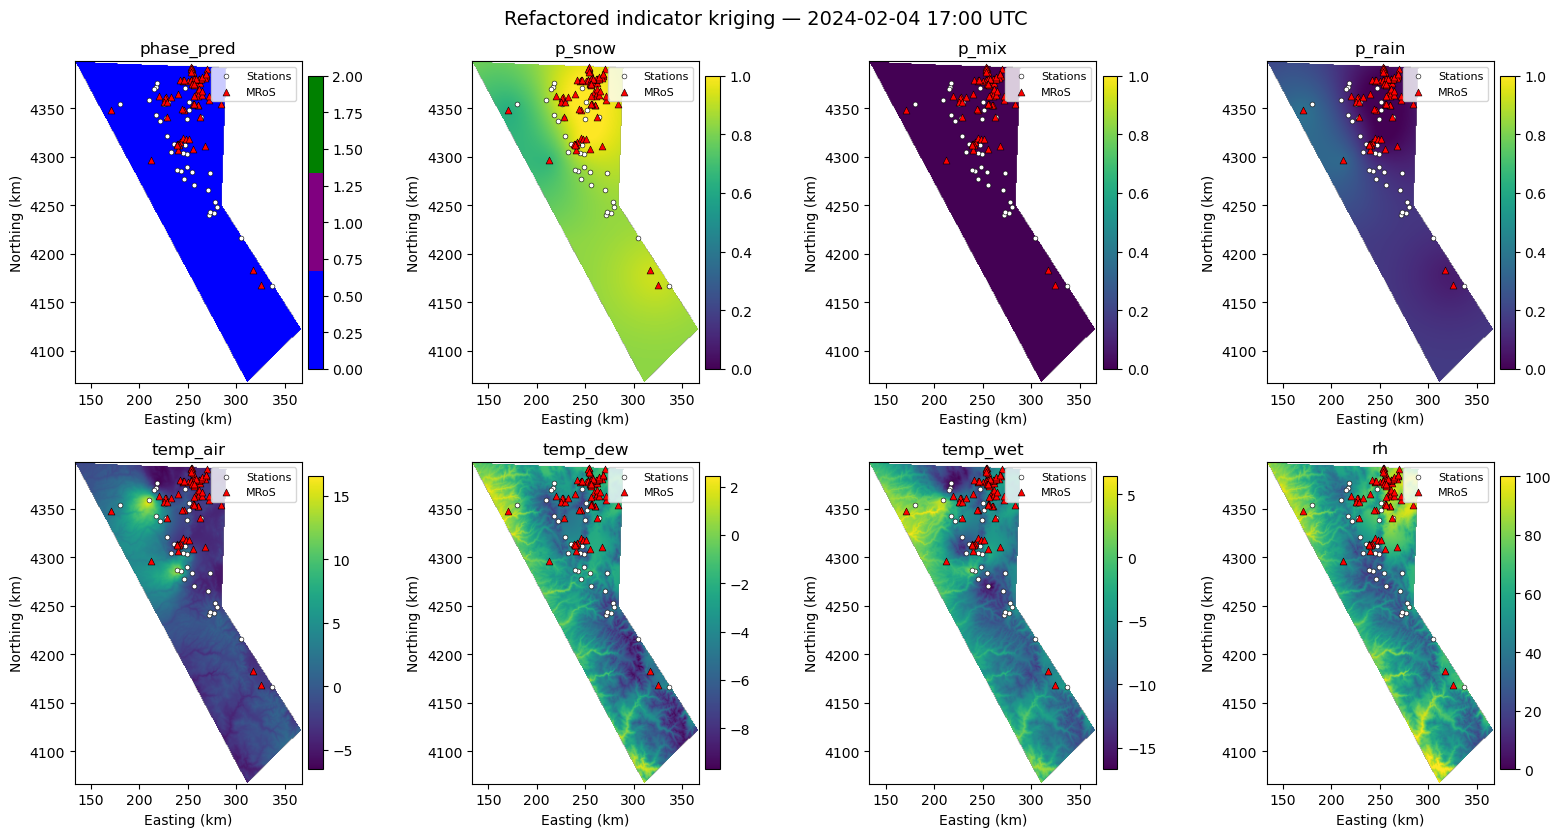


QUICK QC
temp_air   | finite= 36.86% | min=  -6.560 | max=  16.554 | mean=  -0.210
temp_dew   | finite= 36.86% | min=  -9.700 | max=   2.432 | mean=  -3.692
temp_wet   | finite= 36.86% | min= -16.722 | max=   6.417 | mean=  -5.510
rh         | finite= 36.86% | min=  13.821 | max= 100.000 | mean=  57.966
p_snow     | finite= 36.86% | min=   0.623 | max=   1.000 | mean=   0.847
p_mix      | finite= 36.86% | min=   0.000 | max=   0.000 | mean=   0.000
p_rain     | finite= 36.86% | min=   0.000 | max=   0.377 | mean=   0.153

Probability sum check at plotted timestep:
min  = 1.0000
max  = 1.0000
mean = 1.0000
std  = 0.0000

Quicklook complete.


In [9]:
# =============================================================================
# QUICKLOOK – REFACTORED KRIGING SUPPORT SURFACES (SINGLE DATE)
# =============================================================================

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
from pyproj import Transformer, CRS
from matplotlib.colors import ListedColormap


# ------------------------------------------------------------------
# FILE PATHS
# ------------------------------------------------------------------

BASE_DIR   = Path().resolve().parent

TARGET_DATE = "2023-03-15"

# reload from cache — safe to run even if pipeline just finished
cfg = build_config()
st_hr, mros_hr, dem_data, dem_profile, proj_crs = prepare_inputs(cfg, force_rebuild=False)
ds = xr.open_dataset(cfg["out_dir"] / "hourly_predictors_1km_indicator_kriging.nc")

# ------------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------------

print("=" * 80)
print("DATASET SUMMARY")
print("=" * 80)
print(ds)

print("\nVariables in dataset:")
print(list(ds.data_vars))


# ------------------------------------------------------------------
# FIND TIMESTAMP
# ------------------------------------------------------------------

times = pd.to_datetime(ds.time.values).floor("h")
mask = times.normalize() == pd.to_datetime(TARGET_DATE)

if not mask.any():
    raise ValueError(f"No timestep found for {TARGET_DATE}")

# ti = np.where(mask)[0][0]
# t_plot = times[ti]

# find hours with the most MRoS observations in the dataset
mros_counts = (
    mros_hr[mros_hr["mros_phase"].isin(PHASE_ORDER)]
    .groupby("hour_utc")
    .size()
    .sort_values(ascending=False)
)
print("Top 10 hours by MRoS observation count:")
print(mros_counts.head(10))

# use the timestamp with the most MRoS obs
best_ts = mros_counts.index[0]
print(f"Plotting: {best_ts}")
# set ti to the index of that timestamp in the dataset
ti = abs((ds.time.values - best_ts.to_datetime64())).argmin()
t_plot = times[ti]

print("\nPlotting timestep:", t_plot)


# ------------------------------------------------------------------
# GRID EXTENT
# ------------------------------------------------------------------

xmin, xmax = ds.x.min().item(), ds.x.max().item()
ymin, ymax = ds.y.min().item(), ds.y.max().item()
extent = [xmin, xmax, ymin, ymax]


# ------------------------------------------------------------------
# RESOLVE CRS
# ------------------------------------------------------------------

if "spatial_ref" in ds and "crs_wkt" in ds["spatial_ref"].attrs:
    ds_crs = ds["spatial_ref"].attrs["crs_wkt"]
elif "crs" in ds.attrs:
    ds_crs = ds.attrs["crs"]
else:
    # fall back to region config — CRS is known from rcfg
    ds_crs = rcfg["utm_crs"]
    print(f"  No CRS in dataset attrs — using rcfg fallback: {ds_crs}")

tf = Transformer.from_crs("EPSG:4326", CRS.from_user_input(ds_crs), always_xy=True)


# ------------------------------------------------------------------
# FILTER OBS TO MATCHING HOUR
# ------------------------------------------------------------------

if st_hr["hour_utc"].dt.tz is not None:
    st_time = st_hr["hour_utc"].dt.tz_convert(None)
else:
    st_time = st_hr["hour_utc"]

if mros_hr["hour_utc"].dt.tz is not None:
    mros_time = mros_hr["hour_utc"].dt.tz_convert(None)
else:
    mros_time = mros_hr["hour_utc"]

st_t = st_hr[st_time.dt.floor("h") == t_plot].copy()
mros_t = mros_hr[mros_time.dt.floor("h") == t_plot].copy()


# ------------------------------------------------------------------
# PROJECT OBSERVATIONS
# ------------------------------------------------------------------

st_x, st_y = np.array([]), np.array([])
if len(st_t):
    sx, sy = tf.transform(st_t["lon"].values, st_t["lat"].values)
    sx, sy = np.asarray(sx), np.asarray(sy)
    st_mask = (sx >= xmin) & (sx <= xmax) & (sy >= ymin) & (sy <= ymax)
    st_x, st_y = sx[st_mask], sy[st_mask]

mo_x, mo_y = np.array([]), np.array([])
if len(mros_t):
    mx, my = tf.transform(mros_t["lon"].values, mros_t["lat"].values)
    mx, my = np.asarray(mx), np.asarray(my)
    mo_mask = (mx >= xmin) & (mx <= xmax) & (my >= ymin) & (my <= ymax)
    mo_x, mo_y = mx[mo_mask], my[mo_mask]

print(f"Stations in grid: {len(st_x)}")
print(f"MRoS in grid:     {len(mo_x)}")


# ------------------------------------------------------------------
# BUILD PHASE MAP FROM p_snow / p_mix / p_rain
# ------------------------------------------------------------------

p_snow = ds["p_snow"].isel(time=ti).values
p_mix  = ds["p_mix"].isel(time=ti).values
p_rain = ds["p_rain"].isel(time=ti).values

prob_stack = np.stack([p_snow, p_mix, p_rain])  # shape (3, H, W)
any_nan    = ~np.all(np.isfinite(prob_stack), axis=0)
phase_pred = np.argmax(prob_stack, axis=0).astype(float)
phase_pred[any_nan] = np.nan

phase_cmap = ListedColormap(["blue", "purple", "green"])  # snow, mix, rain


# ------------------------------------------------------------------
# VARIABLES TO PLOT
# ------------------------------------------------------------------

vars_to_plot = [
    ("phase_pred", phase_pred),
    ("p_snow", p_snow),
    ("p_mix", p_mix),
    ("p_rain", p_rain),
    ("temp_air", ds["temp_air"].isel(time=ti).values),
    ("temp_dew", ds["temp_dew"].isel(time=ti).values),
    ("temp_wet", ds["temp_wet"].isel(time=ti).values),
    ("rh", ds["rh"].isel(time=ti).values),
]


# ------------------------------------------------------------------
# PLOT
# ------------------------------------------------------------------

fig, axes = plt.subplots(2, 4, figsize=(16, 8.5))
axes = axes.flatten()

fig.suptitle(f"Refactored indicator kriging — {t_plot:%Y-%m-%d %H:%M UTC}", fontsize=14)

for i, (name, arr) in enumerate(vars_to_plot):
    ax = axes[i]

    if name == "phase_pred":
        im = ax.imshow(
            np.ma.masked_invalid(arr),
            origin="lower",
            extent=extent,
            cmap=phase_cmap,
            vmin=0,
            vmax=2,
            aspect="equal"
        )

    elif name in ("p_snow", "p_mix", "p_rain"):
        im = ax.imshow(
            arr,
            origin="lower",
            extent=extent,
            vmin=0,
            vmax=1,
            aspect="equal"
        )

    elif name == "rh":
        im = ax.imshow(
            arr,
            origin="lower",
            extent=extent,
            vmin=0,
            vmax=100,
            aspect="equal"
        )

    else:
        im = ax.imshow(
            arr,
            origin="lower",
            extent=extent,
            aspect="equal"
        )

    ax.set_title(name)
    ax.set_xlabel("Easting (km)")
    ax.set_ylabel("Northing (km)")
    ax.ticklabel_format(style="plain")

    ax.set_xticklabels([f"{x/1000:.0f}" for x in ax.get_xticks()])
    ax.set_yticklabels([f"{y/1000:.0f}" for y in ax.get_yticks()])

    if len(st_x):
        ax.scatter(
            st_x, st_y,
            s=12, c="white", edgecolor="black",
            linewidth=0.4, label="Stations"
        )

    if len(mo_x):
        ax.scatter(
            mo_x, mo_y,
            s=25, c="red", marker="^",
            edgecolor="black", linewidth=0.4,
            label="MRoS"
        )

    ax.legend(loc="upper right", fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------------
# SIMPLE QC PRINTS
# ------------------------------------------------------------------

print("\n" + "=" * 80)
print("QUICK QC")
print("=" * 80)

for v in ["temp_air", "temp_dew", "temp_wet", "rh", "p_snow", "p_mix", "p_rain"]:
    arr = ds[v].isel(time=ti).values
    finite = np.isfinite(arr)
    print(
        f"{v:10s} | finite={finite.mean()*100:6.2f}%"
        f" | min={np.nanmin(arr):8.3f}"
        f" | max={np.nanmax(arr):8.3f}"
        f" | mean={np.nanmean(arr):8.3f}"
    )

p_sum = p_snow + p_mix + p_rain
print("\nProbability sum check at plotted timestep:")
print(f"min  = {np.nanmin(p_sum):.4f}")
print(f"max  = {np.nanmax(p_sum):.4f}")
print(f"mean = {np.nanmean(p_sum):.4f}")
print(f"std  = {np.nanstd(p_sum):.4f}")

print("\nQuicklook complete.")

## Additional diagnostic checks

In [10]:
print(f"p_snow+p_mix+p_rain sum: min={np.nanmin(p_snow+p_mix+p_rain):.4f} max={np.nanmax(p_snow+p_mix+p_rain):.4f}")

p_snow+p_mix+p_rain sum: min=1.0000 max=1.0000


In [11]:
for var in cfg["temp_vars"]:
    if var in st_hr.columns:
        non_nan = st_hr[var].notna().sum()
        total = len(st_hr)
        print(f"{var}: {non_nan:,} / {total:,} non-NaN ({100*non_nan/total:.1f}%)")

temp_air: 757,782 / 1,224,226 non-NaN (61.9%)
temp_dew: 1,224,226 / 1,224,226 non-NaN (100.0%)
temp_wet: 757,782 / 1,224,226 non-NaN (61.9%)


In [12]:
print(list(variogram_params.keys()))

['temp_air_resid', 'temp_dew_resid', 'temp_wet_resid', 'rh', 'p_snow', 'p_mix', 'p_rain']


In [13]:
print("st_hr columns:", list(st_hr.columns))
print()
for var in cfg["temp_vars"]:
    if var in st_hr.columns:
        print(f"{var}: {st_hr[var].notna().sum():,} non-NaN")
    else:
        print(f"{var}: NOT IN COLUMNS")

st_hr columns: ['hour_utc', 'lon', 'lat', 'temp_air', 'temp_dew', 'temp_wet', 'rh', 'x', 'y', 'elev']

temp_air: 757,782 non-NaN
temp_dew: 1,224,226 non-NaN
temp_wet: 757,782 non-NaN


In [14]:
import pandas as pd
raw = pd.read_parquet(cfg["stations_parquet"])
print("Raw parquet columns:", list(raw.columns))
print("Shape:", raw.shape)
print()
for var in ["temp_air", "temp_dew", "temp_wet", "rh"]:
    if var in raw.columns:
        print(f"{var}: {raw[var].notna().sum():,} non-NaN")
    else:
        print(f"{var}: NOT IN RAW PARQUET")

Raw parquet columns: ['id', 'hour_utc', 'temp_air', 'temp_dew', 'rh', 'lat', 'lon', 'elev', 'temp_wet']
Shape: (1225738, 9)

temp_air: 759,294 non-NaN
temp_dew: 1,225,738 non-NaN
temp_wet: 759,294 non-NaN
rh: 1,225,738 non-NaN


In [15]:
# Check the actual distribution of station values at the plotted hour
t_check = pd.Timestamp("2024-02-04 17:00:00", tz="UTC")
st_t = st_hr[st_hr["hour_utc"] == t_check].copy()

print(f"Stations at {t_check}: {len(st_t)} rows")
print()
for var in ["temp_air", "temp_dew", "temp_wet", "rh"]:
    if var in st_t.columns:
        vals = st_t[var].dropna()
        print(f"{var}: n={len(vals)}  min={vals.min():.2f}  max={vals.max():.2f}  mean={vals.mean():.2f}  std={vals.std():.2f}")

print()
# Check elev range of reporting stations
print(f"elev: min={st_t['elev'].min():.0f}m  max={st_t['elev'].max():.0f}m")
print()
# Check how many stations have temp_air vs temp_dew
print(f"stations with temp_air: {st_t['temp_air'].notna().sum()}")
print(f"stations with temp_dew: {st_t['temp_dew'].notna().sum()}")
print(f"stations with temp_wet: {st_t['temp_wet'].notna().sum()}")

Stations at 2024-02-04 17:00:00+00:00: 38 rows

temp_air: n=22  min=-11.67  max=33.89  mean=1.52  std=12.57
temp_dew: n=38  min=-8.61  max=0.00  mean=-4.59  std=2.04
temp_wet: n=22  min=-21.60  max=19.15  mean=-6.75  std=12.70
rh: n=38  min=14.00  max=96.00  mean=47.29  std=29.19

elev: min=1342m  max=2880m

stations with temp_air: 22
stations with temp_dew: 38
stations with temp_wet: 22


In [16]:
for k, v in variogram_params.items():
    print(f"{k}: sill={v['sill']:.4g}, range={v['range']:.0f}m, nugget={v['nugget']:.4g}, psill={v['psill']:.4g}")

temp_air_resid: sill=82.14, range=208280m, nugget=9.354, psill=72.78
temp_dew_resid: sill=20.77, range=69602m, nugget=2.769, psill=18
temp_wet_resid: sill=93.2, range=208280m, nugget=9.546, psill=83.66
rh: sill=325.9, range=117097m, nugget=160, psill=165.9
p_snow: sill=0.1308, range=103878m, nugget=0.1271, psill=0.003722
p_mix: sill=0.1636, range=110722m, nugget=0.08333, psill=0.08025
p_rain: sill=0.1576, range=94881m, nugget=0.08506, psill=0.07251


In [17]:
from sklearn.linear_model import LinearRegression
import numpy as np

t_check = pd.Timestamp("2024-02-04 17:00:00", tz="UTC")
st_t = st_hr[st_hr["hour_utc"] == t_check].copy()

for var in ["temp_air", "temp_wet"]:
    pts = st_t.dropna(subset=["elev", var, "x", "y"]).copy()
    if len(pts) >= 5:
        lr = LinearRegression()
        lr.fit(pts[["elev"]].values, pts[var].values)
        pts["resid"] = pts[var] - (lr.intercept_ + lr.coef_[0] * pts["elev"])
        print(f"{var}: lapse={lr.coef_[0]*1000:.3f}°C/km  intercept={lr.intercept_:.2f}")
        print(f"  resid: min={pts['resid'].min():.3f}  max={pts['resid'].max():.3f}  std={pts['resid'].std():.3f}")
        print()

temp_air: lapse=2.261°C/km  intercept=-3.56
  resid: min=-12.535  max=32.669  std=12.540

temp_wet: lapse=-4.513°C/km  intercept=3.39
  resid: min=-16.159  max=25.293  std=12.579

